Размер данных: (12000, 30)
Первые 5 строк:
   id     num01     num02     num03     num04     num05     num06     num07  \
0   1 -0.946058 -0.070313  1.824445 -2.754422  0.808865 -0.111094 -0.268950   
1   2 -2.484027  0.739378  1.596908 -2.586479 -0.033225 -3.054412 -4.706908   
2   3  1.522629  7.159635 -0.564903 -4.493110  1.623610  5.450187 -0.974595   
3   4  0.463373 -1.073908  1.752813  0.362786  2.790872  4.082385  0.322283   
4   5  3.188390 -4.701692 -0.689918 -0.448995  0.373821 -3.275363 -1.760931   

      num08     num09  ...     num20     num21     num22     num23     num24  \
0 -3.078210  0.801275  ... -1.616515 -1.989464  1.407390 -0.218362  2.016052   
1 -9.795169  0.145911  ... -1.727040 -0.583997  1.136761  0.285978 -0.310879   
2 -5.189589  1.600591  ...  0.524408  2.022430  1.278358 -0.850547  0.847457   
3  3.390984 -0.033929  ...  2.399834 -1.431576 -0.746987  0.049639  2.414689   
4  0.923689  0.537345  ... -2.183407 -2.896590  2.440343 -1.097168  1.457323   

 

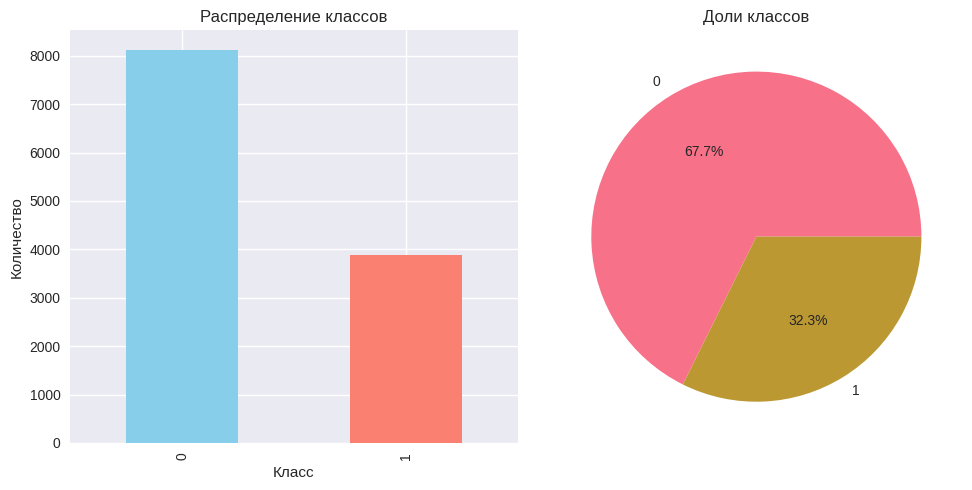

Признаки: 28 шт.
Первые 5 признаков: ['num01', 'num02', 'num03', 'num04', 'num05']
Обучающая выборка (train): 7200 samples
Валидационная выборка (val): 2400 samples
Тестовая выборка (test): 2400 samples
Всего: 12000 samples

Доля положительного класса в train: 0.323
Доля положительного класса в val: 0.323
Доля положительного класса в test: 0.323
=== Dummy Classifier (стратегия: most_frequent) ===
CV Accuracy: 0.6766 ± 0.0000
CV F1: 0.0000 ± 0.0000

=== Logistic Regression ===
CV Accuracy: 0.8334 ± 0.0051
CV F1: 0.7183 ± 0.0117
CV ROC-AUC: 0.8822 ± 0.0065
=== Decision Tree Classifier ===
Обучение Decision Tree с GridSearchCV на train...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Лучшие параметры: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10}
Лучший ROC-AUC (CV на train): 0.9034
ROC-AUC на validation: 0.9033


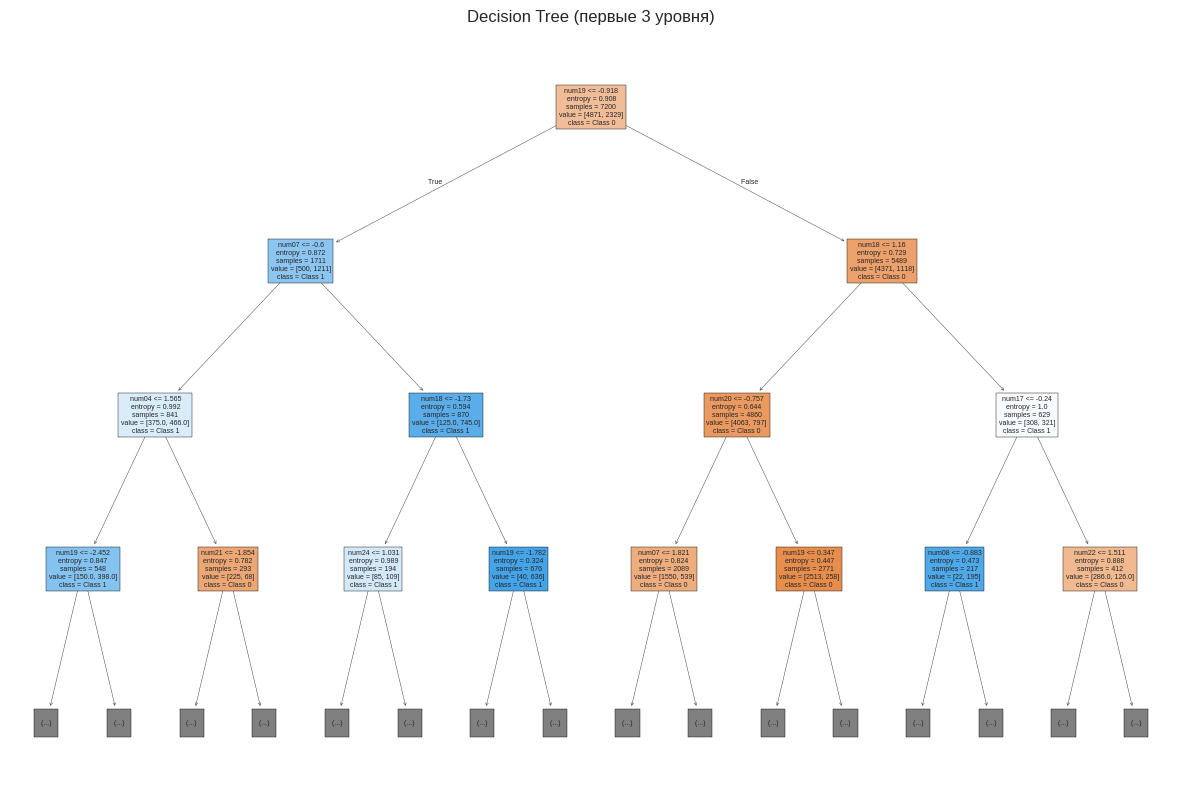

=== Random Forest Classifier ===
Обучение Random Forest с GridSearchCV на train...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Лучший ROC-AUC (CV на train): 0.9673
ROC-AUC на validation: 0.9680


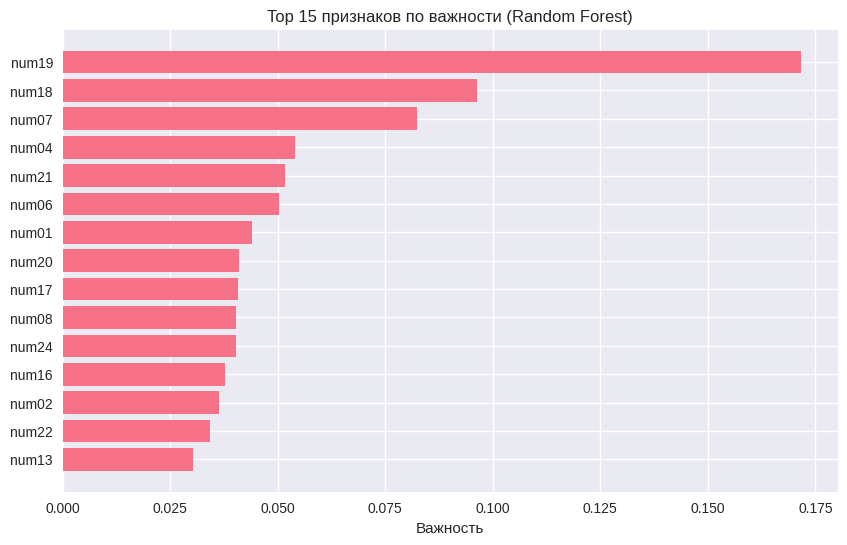

=== Gradient Boosting Classifier ===
Обучение Gradient Boosting с GridSearchCV на train...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Лучший ROC-AUC (CV на train): 0.9691
ROC-AUC на validation: 0.9710
=== Обучение финальных моделей на train+val ===
Все модели обучены на train+val для финальной оценки на test
=== Stacking Classifier ===
Stacking Classifier обучен на train+val
=== Финальная оценка на тестовой выборке ===
Важно: тестовая выборка используется только один раз!

--- Оценка Dummy ---
Test Accuracy: 0.6767
Test F1: 0.0000
Test ROC-AUC: 0.5000

--- Оценка LogisticRegression ---
Test Accuracy: 0.8275
Test F1: 0.7076
Test ROC-AUC: 0.8747

--- Оценка DecisionTree ---
Test Accuracy: 0.8675
Test F1: 0.7857
Test ROC-AUC: 0.8982

--- Оценка RandomForest ---
Test Accuracy: 0.9292
Test F1: 0.8854
Test ROC-AUC: 0.9673

--- Оценка GradientBoosting ---
Test Accuracy: 0.9375
Tes

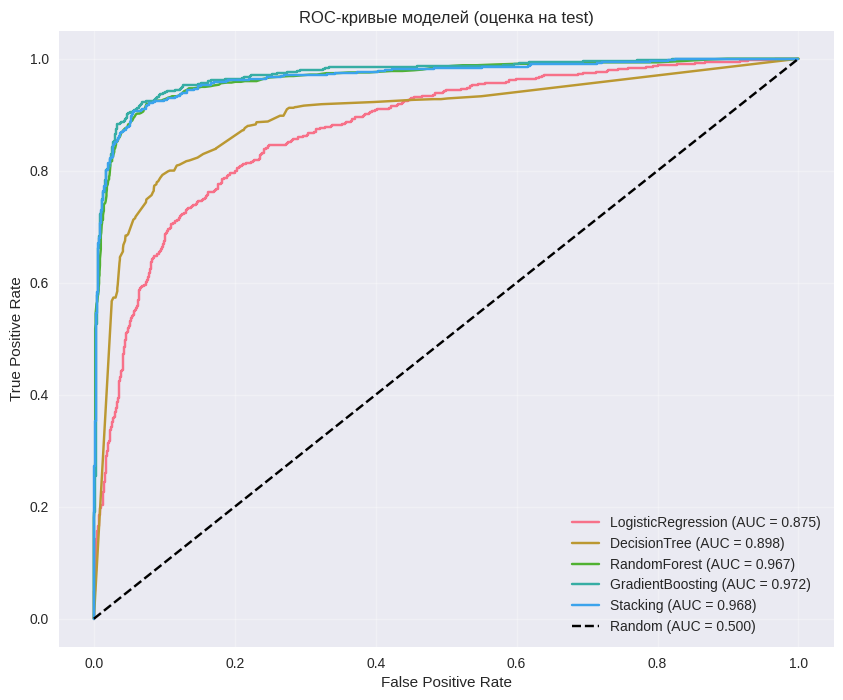

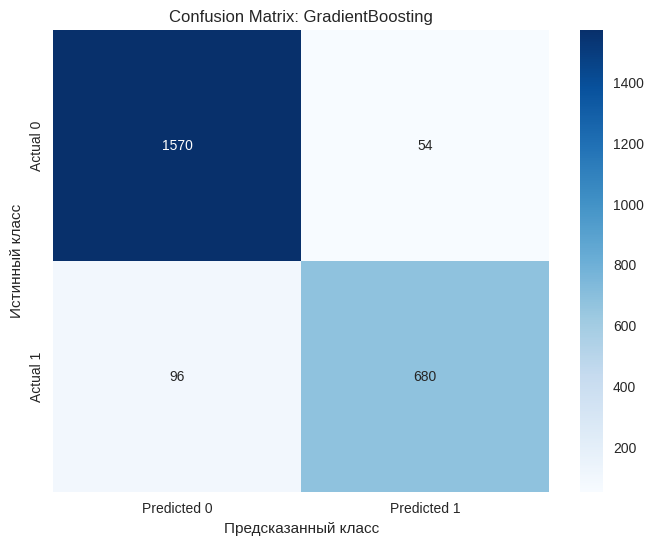

=== Permutation Importance для лучшей модели (GradientBoosting) ===
Top 15 признаков по permutation importance (на validation):
          feature  importance_mean  importance_std
17          num18         0.050869        0.003824
18          num19         0.042025        0.002494
6           num07         0.018669        0.001127
3           num04         0.004977        0.000594
23          num24         0.003001        0.000346
19          num20         0.002684        0.000453
0           num01         0.001701        0.000376
21          num22         0.001168        0.000382
13          num14         0.001147        0.000221
14          num15         0.001055        0.000094
20          num21         0.000868        0.000172
27  tenure_months         0.000817        0.000057
15          num16         0.000719        0.000118
16          num17         0.000494        0.000140
8           num09         0.000344        0.000175


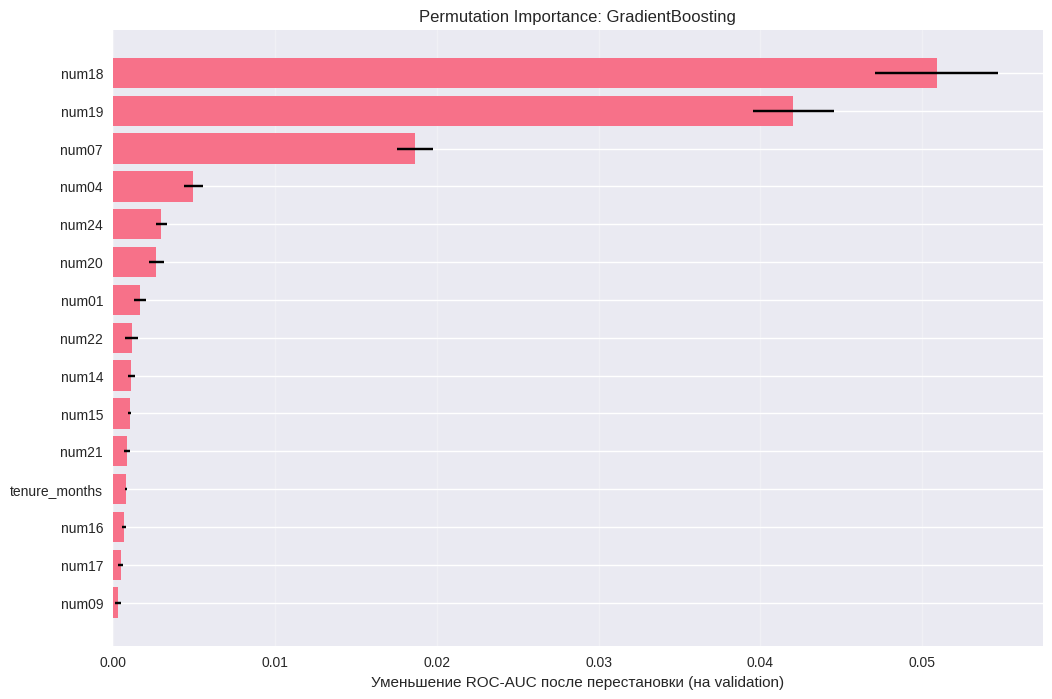


✅ Артефакты успешно сохранены!
1. Лучшая модель: artifacts/best_model.joblib
2. Метаданные: artifacts/best_model_meta.json
3. Метрики на test: artifacts/metrics_test.csv
4. Графики: artifacts/figures/


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, precision_recall_curve, auc
)
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
import joblib
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройки для красивого отображения
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Создаем папки для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

# %% [markdown]
# ## 2. Загрузка данных и первичный анализ

# %%
# Загрузка данных
df = pd.read_csv('S06-hw-dataset-01.csv')
print(f"Размер данных: {df.shape}")

# %%
# Первичный анализ
print("Первые 5 строк:")
print(df.head())
print("\n" + "="*50 + "\n")

print("Информация о данных:")
print(df.info())
print("\n" + "="*50 + "\n")

print("Базовые статистики:")
print(df.describe())
print("\n" + "="*50 + "\n")

# Проверка пропусков
print("Пропуски в данных:")
print(df.isnull().sum())

# %%
# Анализ целевой переменной
print("Распределение целевой переменной:")
target_dist = df['target'].value_counts(normalize=True)
print(target_dist)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
plt.pie(target_dist.values, labels=target_dist.index, autopct='%1.1f%%')
plt.title('Доли классов')
plt.tight_layout()
plt.savefig('artifacts/figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 3. Подготовка данных и честный train/val/test сплит

# %%
# Отделяем признаки и целевую переменную
if 'id' in df.columns:
    X = df.drop(['target', 'id'], axis=1)
else:
    X = df.drop('target', axis=1)
y = df['target']

print(f"Признаки: {X.shape[1]} шт.")
print(f"Первые 5 признаков: {list(X.columns[:5])}")

# %% [markdown]
# ## 4. Честное разделение на train/val/test
#
# **Важно**: test set используется только один раз в самом конце для финальной оценки

# %%
# Первое разделение: train_val (80%) и test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Второе разделение: train (60%) и val (20%) от исходных данных
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,  # 20% от исходных данных (0.25 * 0.8 = 0.2)
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print(f"Обучающая выборка (train): {X_train.shape[0]} samples")
print(f"Валидационная выборка (val): {X_val.shape[0]} samples")
print(f"Тестовая выборка (test): {X_test.shape[0]} samples")
print(f"Всего: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} samples")
print()
print(f"Доля положительного класса в train: {y_train.mean():.3f}")
print(f"Доля положительного класса в val: {y_val.mean():.3f}")
print(f"Доля положительного класса в test: {y_test.mean():.3f}")

# %% [markdown]
# ## 5. Baseline модели с оценкой через кросс-валидацию

# %%
# Метрики для сохранения
cv_results = {}
test_results = {}

def evaluate_model_cv(model, model_name, X_data, y_data, scoring='roc_auc'):
    """Оценка модели через кросс-валидацию на train/val данных"""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    # Оценка accuracy
    accuracy_scores = cross_val_score(model, X_data, y_data,
                                     cv=cv, scoring='accuracy', n_jobs=-1)

    # Оценка f1
    f1_scores = cross_val_score(model, X_data, y_data,
                               cv=cv, scoring='f1', n_jobs=-1)

    # Оценка roc_auc (если модель поддерживает вероятности)
    roc_auc_scores = None
    if hasattr(model, 'predict_proba'):
        try:
            roc_auc_scores = cross_val_score(model, X_data, y_data,
                                           cv=cv, scoring='roc_auc', n_jobs=-1)
        except:
            roc_auc_scores = None

    results = {
        'cv_accuracy_mean': accuracy_scores.mean(),
        'cv_accuracy_std': accuracy_scores.std(),
        'cv_f1_mean': f1_scores.mean(),
        'cv_f1_std': f1_scores.std(),
    }

    if roc_auc_scores is not None:
        results['cv_roc_auc_mean'] = roc_auc_scores.mean()
        results['cv_roc_auc_std'] = roc_auc_scores.std()

    cv_results[model_name] = results
    return results

def evaluate_model_test(model, X_test_data, y_test_data):
    """Финальная оценка модели на тестовых данных (вызывается один раз!)"""
    y_pred = model.predict(X_test_data)
    y_pred_proba = None

    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_data)[:, 1]

    metrics = {
        'test_accuracy': accuracy_score(y_test_data, y_pred),
        'test_f1': f1_score(y_test_data, y_pred)
    }

    if y_pred_proba is not None:
        metrics['test_roc_auc'] = roc_auc_score(y_test_data, y_pred_proba)

    return metrics

# %%
# 1. Dummy Classifier (оценка через CV)
print("=== Dummy Classifier (стратегия: most_frequent) ===")
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_cv_metrics = evaluate_model_cv(dummy_clf, 'Dummy', X_train_val, y_train_val)
print(f"CV Accuracy: {dummy_cv_metrics['cv_accuracy_mean']:.4f} ± {dummy_cv_metrics['cv_accuracy_std']:.4f}")
print(f"CV F1: {dummy_cv_metrics['cv_f1_mean']:.4f} ± {dummy_cv_metrics['cv_f1_std']:.4f}")
print()

# %%
# 2. Logistic Regression (оценка через CV)
print("=== Logistic Regression ===")
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1))
])

lr_cv_metrics = evaluate_model_cv(lr_pipeline, 'LogisticRegression', X_train_val, y_train_val)
print(f"CV Accuracy: {lr_cv_metrics['cv_accuracy_mean']:.4f} ± {lr_cv_metrics['cv_accuracy_std']:.4f}")
print(f"CV F1: {lr_cv_metrics['cv_f1_mean']:.4f} ± {lr_cv_metrics['cv_f1_std']:.4f}")
print(f"CV ROC-AUC: {lr_cv_metrics.get('cv_roc_auc_mean', 'N/A'):.4f} ± {lr_cv_metrics.get('cv_roc_auc_std', 'N/A'):.4f}")

# %% [markdown]
# ## 6. Модели деревьев и ансамблей с GridSearchCV на train

# %% [markdown]
# ### 6.1. Decision Tree с контролем сложности

# %%
print("=== Decision Tree Classifier ===")

# Настройка параметров для дерева
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Поиск по сетке с кросс-валидацией ТОЛЬКО на train
grid_dt = GridSearchCV(
    dt, param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Обучение Decision Tree с GridSearchCV на train...")
grid_dt.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_dt.best_params_}")
print(f"Лучший ROC-AUC (CV на train): {grid_dt.best_score_:.4f}")

# Оценка на валидационной выборке для проверки
best_dt = grid_dt.best_estimator_
best_dt.fit(X_train, y_train)  # Переобучаем на train
y_val_pred_proba = best_dt.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)
print(f"ROC-AUC на validation: {val_roc_auc:.4f}")

# Визуализация дерева
plt.figure(figsize=(15, 10))
plot_tree(best_dt, filled=True, feature_names=X.columns,
          class_names=['Class 0', 'Class 1'], max_depth=3)
plt.title('Decision Tree (первые 3 уровня)')
plt.savefig('artifacts/figures/decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 6.2. Random Forest

# %%
print("=== Random Forest Classifier ===")

# Упрощенная сетка для скорости
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

grid_rf = GridSearchCV(
    rf, param_grid_rf,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Обучение Random Forest с GridSearchCV на train...")
grid_rf.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Лучший ROC-AUC (CV на train): {grid_rf.best_score_:.4f}")

# Оценка на валидационной выборке
best_rf = grid_rf.best_estimator_
best_rf.fit(X_train, y_train)
y_val_pred_proba = best_rf.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)
print(f"ROC-AUC на validation: {val_roc_auc:.4f}")

# Важность признаков
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Важность')
plt.title('Top 15 признаков по важности (Random Forest)')
plt.gca().invert_yaxis()
plt.savefig('artifacts/figures/feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 6.3. Gradient Boosting

# %%
print("=== Gradient Boosting Classifier ===")

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

grid_gb = GridSearchCV(
    gb, param_grid_gb,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Обучение Gradient Boosting с GridSearchCV на train...")
grid_gb.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_gb.best_params_}")
print(f"Лучший ROC-AUC (CV на train): {grid_gb.best_score_:.4f}")

# Оценка на валидационной выборке
best_gb = grid_gb.best_estimator_
best_gb.fit(X_train, y_train)
y_val_pred_proba = best_gb.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)
print(f"ROC-AUC на validation: {val_roc_auc:.4f}")

# %% [markdown]
# ### 6.4. Обучение всех моделей на train+val для финальной оценки

# %%
print("=== Обучение финальных моделей на train+val ===")

# Словарь для хранения обученных моделей
trained_models = {}

# 1. Dummy Classifier
dummy_final = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_final.fit(X_train_val, y_train_val)
trained_models['Dummy'] = dummy_final

# 2. Logistic Regression
lr_final = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1))
])
lr_final.fit(X_train_val, y_train_val)
trained_models['LogisticRegression'] = lr_final

# 3. Decision Tree
dt_final = grid_dt.best_estimator_
dt_final.fit(X_train_val, y_train_val)
trained_models['DecisionTree'] = dt_final

# 4. Random Forest
rf_final = grid_rf.best_estimator_
rf_final.fit(X_train_val, y_train_val)
trained_models['RandomForest'] = rf_final

# 5. Gradient Boosting
gb_final = grid_gb.best_estimator_
gb_final.fit(X_train_val, y_train_val)
trained_models['GradientBoosting'] = gb_final

print("Все модели обучены на train+val для финальной оценки на test")

# %% [markdown]
# ### 6.5. Stacking (опционально) - обучение на train+val

# %%
print("=== Stacking Classifier ===")

# Базовые модели
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
]

# Мета-модель
meta_model = LogisticRegression(random_state=RANDOM_STATE)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# Обучение стекинга на train+val
stacking_clf.fit(X_train_val, y_train_val)
trained_models['Stacking'] = stacking_clf

print("Stacking Classifier обучен на train+val")

# %% [markdown]
# ## 7. Финальная оценка на тестовой выборке (один раз!)

# %%
print("=== Финальная оценка на тестовой выборке ===")
print("Важно: тестовая выборка используется только один раз!\n")

# Финальная оценка всех моделей
final_test_metrics = {}

for model_name, model in trained_models.items():
    print(f"--- Оценка {model_name} ---")
    metrics = evaluate_model_test(model, X_test, y_test)
    final_test_metrics[model_name] = metrics

    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")
    if 'test_roc_auc' in metrics:
        print(f"Test ROC-AUC: {metrics['test_roc_auc']:.4f}")
    print()

# Сводная таблица метрик
test_metrics_df = pd.DataFrame(final_test_metrics).T
print("\n=== Сводная таблица метрик на test ===")
print(test_metrics_df.to_string(float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

# Сохранение метрик
test_metrics_df.to_csv('artifacts/metrics_test.csv')

# Определение лучшей модели по ROC-AUC
best_model_name = None
best_roc_auc = 0

for model_name, metrics in final_test_metrics.items():
    if 'test_roc_auc' in metrics and metrics['test_roc_auc'] > best_roc_auc:
        best_roc_auc = metrics['test_roc_auc']
        best_model_name = model_name

print(f"\n✅ Лучшая модель по ROC-AUC: {best_model_name}")
print(f"   ROC-AUC на test: {best_roc_auc:.4f}")

# %% [markdown]
# ## 8. Сравнение моделей и визуализация

# %%
# ROC-кривые
plt.figure(figsize=(10, 8))

models_with_proba = ['LogisticRegression', 'DecisionTree', 'RandomForest',
                     'GradientBoosting', 'Stacking']

for model_name in models_with_proba:
    if model_name in trained_models:
        model = trained_models[model_name]
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            roc_auc = roc_auc_score(y_test, y_pred_proba)
            plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей (оценка на test)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('artifacts/figures/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# Confusion Matrix для лучшей модели
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.savefig('artifacts/figures/confusion_matrix_best.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 9. Интерпретация лучшей модели

# %%
print(f"=== Permutation Importance для лучшей модели ({best_model_name}) ===")

# Вычисляем permutation importance НА ВАЛИДАЦИОННОЙ выборке
result = permutation_importance(
    best_model, X_val, y_val,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='roc_auc'
)

# Создаем DataFrame с результатами
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False).head(15)

print("Top 15 признаков по permutation importance (на validation):")
print(importance_df)

# Визуализация
plt.figure(figsize=(12, 8))
plt.barh(importance_df['feature'], importance_df['importance_mean'],
         xerr=importance_df['importance_std'])
plt.xlabel('Уменьшение ROC-AUC после перестановки (на validation)')
plt.title(f'Permutation Importance: {best_model_name}')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.savefig('artifacts/figures/permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 10. Сохранение артефактов

# %%
# 1. Сохраняем лучшую модель
joblib.dump(best_model, 'artifacts/best_model.joblib')

# 2. Сохраняем метаданные лучшей модели
best_model_meta = {
    'model_name': best_model_name,
    'best_params': str(getattr(best_model, 'best_params_', 'N/A')),
    'test_metrics': final_test_metrics[best_model_name],
    'cv_scores': {
        'DecisionTree': {
            'best_params': grid_dt.best_params_,
            'best_score': grid_dt.best_score_,
            'validation_roc_auc': roc_auc_score(y_val, grid_dt.best_estimator_.predict_proba(X_val)[:, 1])
        },
        'RandomForest': {
            'best_params': grid_rf.best_params_,
            'best_score': grid_rf.best_score_,
            'validation_roc_auc': roc_auc_score(y_val, grid_rf.best_estimator_.predict_proba(X_val)[:, 1])
        },
        'GradientBoosting': {
            'best_params': grid_gb.best_params_,
            'best_score': grid_gb.best_score_,
            'validation_roc_auc': roc_auc_score(y_val, grid_gb.best_estimator_.predict_proba(X_val)[:, 1])
        }
    },
    'timestamp': datetime.now().isoformat(),
    'dataset': 'S06-hw-dataset-01.csv',
    'random_state': RANDOM_STATE,
    'data_split': {
        'train_size': X_train.shape[0],
        'val_size': X_val.shape[0],
        'test_size': X_test.shape[0],
        'train_val_size': X_train_val.shape[0]
    }
}

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_model_meta, f, indent=2, ensure_ascii=False)

# 3. Сохраняем результаты поиска гиперпараметров
search_results = {
    'DecisionTree': {
        'best_params': grid_dt.best_params_,
        'best_cv_score': grid_dt.best_score_,
        'validation_score': roc_auc_score(y_val, grid_dt.best_estimator_.predict_proba(X_val)[:, 1])
    },
    'RandomForest': {
        'best_params': grid_rf.best_params_,
        'best_cv_score': grid_rf.best_score_,
        'validation_score': roc_auc_score(y_val, grid_rf.best_estimator_.predict_proba(X_val)[:, 1])
    },
    'GradientBoosting': {
        'best_params': grid_gb.best_params_,
        'best_cv_score': grid_gb.best_score_,
        'validation_score': roc_auc_score(y_val, grid_gb.best_estimator_.predict_proba(X_val)[:, 1])
    }
}

with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(search_results, f, indent=2, ensure_ascii=False)

print("\n✅ Артефакты успешно сохранены!")
print(f"1. Лучшая модель: artifacts/best_model.joblib")
print(f"2. Метаданные: artifacts/best_model_meta.json")
print(f"3. Метрики на test: artifacts/metrics_test.csv")
print(f"4. Графики: artifacts/figures/")